# Titanic dataset analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# 1.Load Dataset

In [2]:
df=pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Shape of Dataset:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(891, 12)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
F

# 2.clean dataset

In [4]:
df['Age'].fillna(df['Age'].median())

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [5]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [6]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


# Question 1:
 # Who Survived More: Males or Females?

In [7]:
survival_gender = df.groupby('Sex')['Survived'].mean()*100

print("Survival Percentage by Gender:")
print(survival_gender)

Survival Percentage by Gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


# Question 2:
# Did Passenger Class Affect Survival?

In [8]:
class_survival = df.groupby('Pclass')['Survived'].mean()*100

print(class_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


# Question 3:
# Survival Rate by Age Group

In [9]:
bins = [0,12,18,35,60,100]
labels = ['Child','Teen','Young Adult','Adult','Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [10]:
age_survival = df.groupby('AgeGroup')['Survived'].mean()

print(age_survival)

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.382682
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


# 3. visualiazation

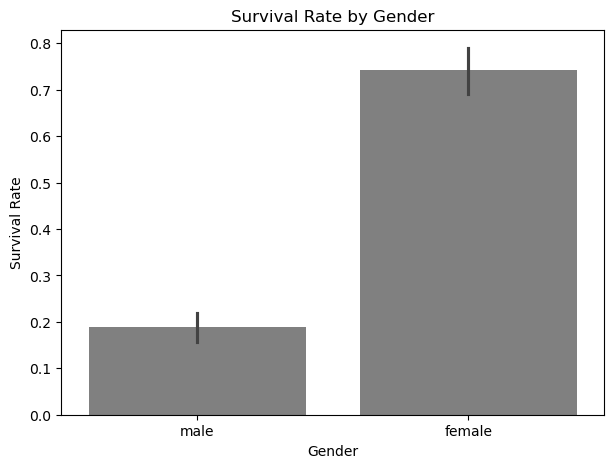

In [11]:
plt.figure(figsize=(7,5))
sns.barplot(x='Sex', y='Survived', data=df,color='grey')

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

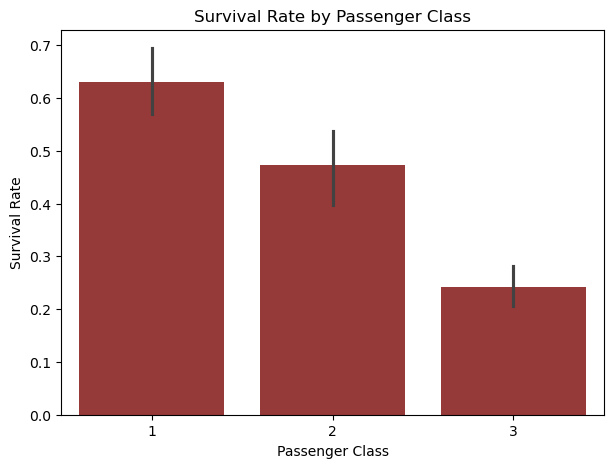

In [12]:
plt.figure(figsize=(7,5))
sns.barplot(x='Pclass', y='Survived', data=df,color='brown')

plt.title('Survival Rate by Passenger Class') 
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

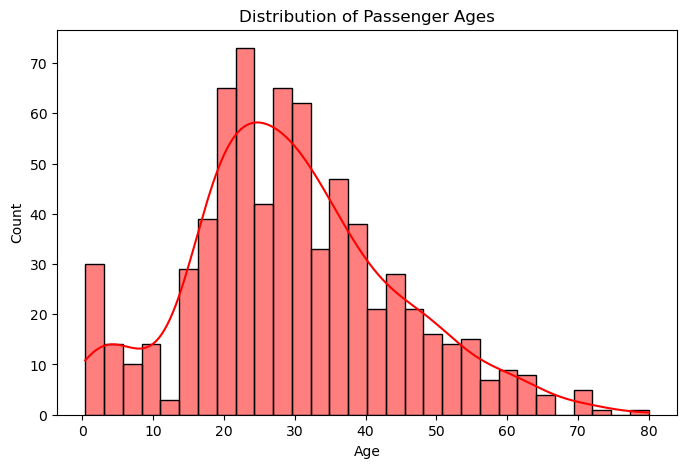

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'],
             bins=30,
             kde=True,color='red')

plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()